# Voter model: how local copying shapes collective outcomes

Agents repeatedly copy the state of a network neighbor. This minimal stochastic mechanism lets us ask:

- Can local copying produce global consensus?
- Does disagreement decrease smoothly, or can it fluctuate?
- How does network position affect the probability of the final outcome?

The model is useful because it isolates one mechanism—social copying—and makes its consequences measurable.

## The network voter model

Each agent $i$ has one of two discrete states:

$$
s_i(\tau) \in \{0,1\}.
$$

At each microscopic update, choose a focal agent $i$ uniformly. Then choose one of its neighbors $j$ uniformly and copy that neighbor:

$$
s_i(\tau+1)=s_j(\tau),
$$

while every other state remains unchanged. This is the asynchronous **node-update** voter model; link-update and synchronous variants are different models.

### Conventions used here

- **State space:** binary states $0$ and $1$.
- **Population:** 100 agents.
- **Topology:** one fixed, simple, connected, undirected Barabási–Albert network created with igraph.
- **Initial state:** states are independent Bernoulli draws with probability INITIAL_ONE_PROBABILITY of state $1$.
- **Update schedule:** asynchronous node-update with sampling repeated independently at every microscopic update.
- **Isolated agents:** they keep their state; the connected baseline network has none.
- **Time:** one sweep is N_AGENTS attempted microscopic updates.
- **Stopping rule:** stop after a consensus sweep or after MAX_SWEEPS.
- **Consensus:** all agents have exactly the same binary state.
- **Observables:** state-$1$ density and active-edge density, the fraction of edges joining different states.
- **Threshold convention:** no confidence threshold is used.
- **Parameter ranges:** N_AGENTS >= 2, 1 <= EDGES_PER_NEW_AGENT < N_AGENTS, 0 <= INITIAL_ONE_PROBABILITY <= 1, MAX_SWEEPS > 0, and N_ENSEMBLE_RUNS > 0.

On a finite connected network, the only absorbing configurations are all-$0$ and all-$1$. A single stochastic realization illustrates one possible path; it does not describe every run.

### Historical reference

The earliest primary precursor is Peter Clifford and Aidan Sudbury, **“A model for spatial conflict,”** *Biometrika* 60(3), 581–588 (1973), [doi:10.1093/biomet/60.3.581](https://doi.org/10.1093/biomet/60.3.581). Holley and Liggett introduced the name *voter model* in 1975; full references appear at the end.

In [8]:
import random

import igraph as ig
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
EDGES_PER_NEW_AGENT = 3
INITIAL_ONE_PROBABILITY = 0.50
MAX_SWEEPS = 500
N_ENSEMBLE_RUNS = 200

# Independent fixed seeds make each stochastic component reproducible.
NETWORK_SEED = 2031
INITIAL_STATE_SEED = 2032
SIMULATION_SEED = 2033
LAYOUT_SEED = 2034
ENSEMBLE_SEED = 2035

assert N_AGENTS >= 2
assert 1 <= EDGES_PER_NEW_AGENT < N_AGENTS
assert 0 <= INITIAL_ONE_PROBABILITY <= 1
assert MAX_SWEEPS > 0
assert N_ENSEMBLE_RUNS > 0

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create the network and initial state

A Barabási–Albert network gives agents different degrees, making network position relevant to the stochastic outcome. It is a synthetic interaction structure, not a reconstruction of a real social network.

igraph creates, stores, lays out, and draws the network. The force-directed layout affects only the visualization, never the update rule.

In [9]:
# igraph uses this seeded generator for reproducible network growth.
ig.set_random_number_generator(random.Random(NETWORK_SEED))
graph_ig = ig.Graph.Barabasi(
    n=N_AGENTS,
    m=EDGES_PER_NEW_AGENT,
    directed=False,
)

assert graph_ig.vcount() == N_AGENTS
assert graph_ig.is_simple(), "The interaction network must be simple."
assert graph_ig.is_connected(), "The interaction network must be connected."
assert graph_ig.vs.indices == list(range(N_AGENTS))

neighbor_ids = [
    np.asarray(graph_ig.neighbors(vertex), dtype=int)
    for vertex in range(N_AGENTS)
]
edge_array = np.asarray(graph_ig.get_edgelist(), dtype=int)
degrees = np.asarray(graph_ig.degree(), dtype=float)

# Seed the layout independently from the network and dynamics.
layout_rng = np.random.default_rng(LAYOUT_SEED)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = graph_ig.layout_fruchterman_reingold(
    seed=layout_start.tolist(),
)

initial_state_rng = np.random.default_rng(INITIAL_STATE_SEED)
initial_states = (
    initial_state_rng.random(N_AGENTS) < INITIAL_ONE_PROBABILITY
).astype(np.int8)

assert len(layout) == N_AGENTS
assert edge_array.shape == (graph_ig.ecount(), 2)
assert set(np.unique(initial_states)).issubset({0, 1})

print(f"Agents: {graph_ig.vcount()}")
print(f"Connections: {graph_ig.ecount()}")
print(f"Mean degree: {degrees.mean():.2f}")
print(f"Initial fraction in state 1: {initial_states.mean():.3f}")

Agents: 100
Connections: 294
Mean degree: 5.88
Initial fraction in state 1: 0.490


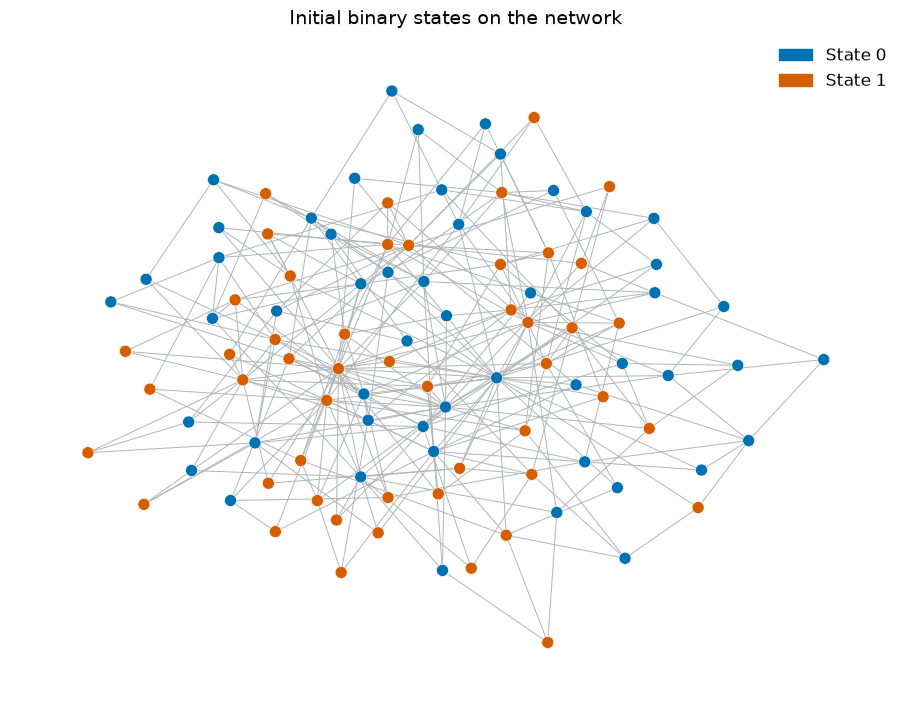

In [10]:
STATE_COLORS = np.array(["#0072B2", "#D55E00"])
state_legend = [
    mpatches.Patch(color=STATE_COLORS[state], label=f"State {state}")
    for state in (0, 1)
]


def draw_voter_network(ax, states, title, vertex_size):
    """Draw binary states on the igraph network in vertex-ID order."""
    assert len(states) == graph_ig.vcount()
    vertex_colors = [STATE_COLORS[int(state)] for state in states]

    ig.plot(
        graph_ig,
        target=ax,
        layout=layout,
        vertex_color=vertex_colors,
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=False,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
draw_voter_network(
    ax,
    initial_states,
    "Initial binary states on the network",
    vertex_size=12,
)
ax.legend(handles=state_legend, loc="upper right", frameon=False)
plt.show()

## 2. Implement asynchronous node-update

Each call to voter_sweep performs exactly N_AGENTS attempted updates. Focal agents and neighbors are sampled with replacement, so an agent may update several times—or not at all—within one sweep.

The simulation records the state only at sweep boundaries. Once consensus is reached, copying cannot change the configuration.

In [11]:
def apply_copy(states, focal_agent, model_agent):
    """Mutate one focal state by copying the selected model agent."""
    states[focal_agent] = states[model_agent]


def voter_sweep(states, neighbors, rng):
    """Perform len(states) asynchronous node-update attempts in place."""
    for _ in range(len(states)):
        focal_agent = int(rng.integers(len(states)))
        focal_neighbors = neighbors[focal_agent]
        if focal_neighbors.size == 0:
            continue

        model_index = int(rng.integers(focal_neighbors.size))
        model_agent = int(focal_neighbors[model_index])
        apply_copy(states, focal_agent, model_agent)


def active_edge_density(states, edges):
    """Return the fraction of edges joining different states."""
    if len(edges) == 0:
        return 0.0
    return np.mean(states[edges[:, 0]] != states[edges[:, 1]])


def simulate_voter(neighbors, edges, initial_state, max_sweeps, rng):
    """Record states and observables until consensus or max_sweeps."""
    states = np.asarray(initial_state, dtype=np.int8).copy()
    history = [states.copy()]
    active_history = [active_edge_density(states, edges)]

    consensus_sweep = 0 if np.all(states == states[0]) else None
    for sweep in range(1, max_sweeps + 1):
        if consensus_sweep is not None:
            break

        voter_sweep(states, neighbors, rng)
        history.append(states.copy())
        active_history.append(active_edge_density(states, edges))

        if np.all(states == states[0]):
            consensus_sweep = sweep

    return (
        np.asarray(history, dtype=np.int8),
        np.asarray(active_history, dtype=float),
        consensus_sweep,
    )


# Hand-check the elementary copying rule.
test_states = np.array([0, 1], dtype=np.int8)
apply_copy(test_states, focal_agent=0, model_agent=1)
assert np.array_equal(test_states, [1, 1])

simulation_rng = np.random.default_rng(SIMULATION_SEED)
state_history, active_history, consensus_sweep = simulate_voter(
    neighbor_ids,
    edge_array,
    initial_states,
    MAX_SWEEPS,
    simulation_rng,
)

assert state_history.shape[1] == N_AGENTS
assert len(active_history) == len(state_history)
assert set(np.unique(state_history)).issubset({0, 1})

final_states = state_history[-1]
elapsed_sweeps = len(state_history) - 1
consensus_outcome = (
    int(final_states[0]) if consensus_sweep is not None else None
)

## 3. Compare the initial and final configurations

The panels use the same network layout and state colors. Unlike DeGroot averaging, agents remain in one of two discrete states throughout the process.

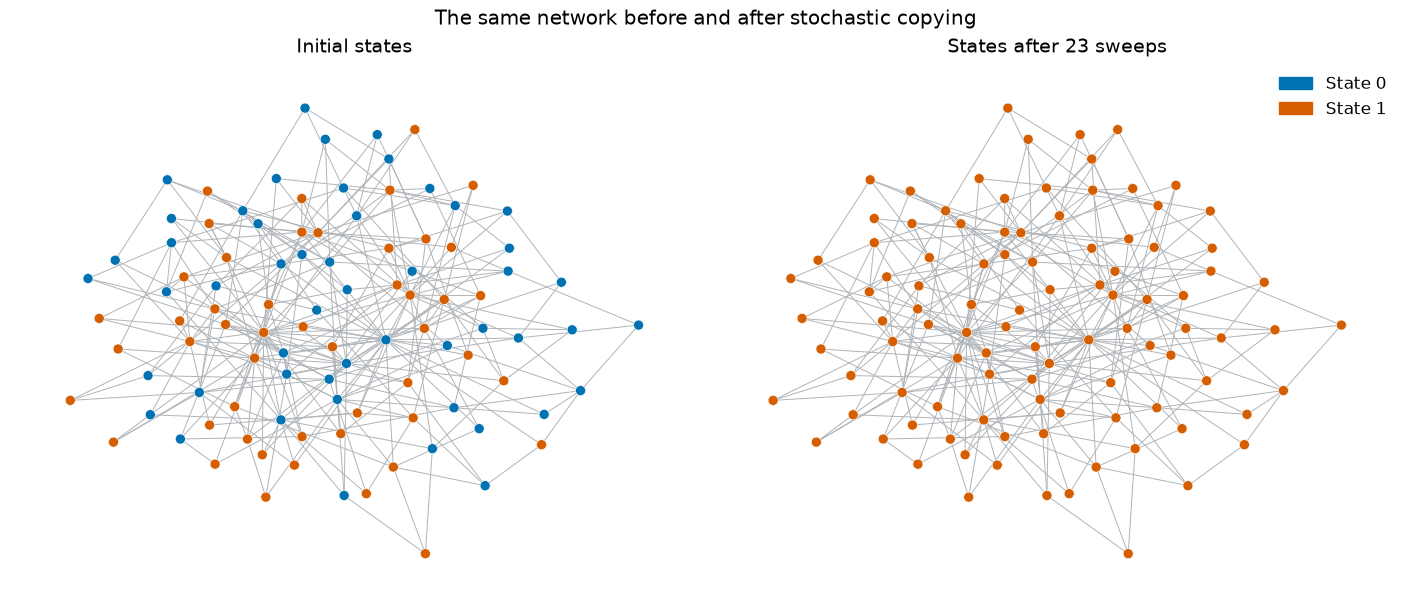

Consensus on state 1 after 23 sweeps.


In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    layout="constrained",
)

states_to_draw = [
    (initial_states, "Initial states"),
    (final_states, f"States after {elapsed_sweeps} sweeps"),
]

for ax, (states, title) in zip(axes, states_to_draw):
    draw_voter_network(ax, states, title, vertex_size=10)

axes[1].legend(handles=state_legend, loc="upper right", frameon=False)
fig.suptitle("The same network before and after stochastic copying")
plt.show()

if consensus_sweep is None:
    print(f"No consensus within {MAX_SWEEPS} sweeps.")
else:
    print(
        f"Consensus on state {consensus_outcome} "
        f"after {consensus_sweep} sweeps."
    )

## 4. Follow density and disagreement

The ordinary state-$1$ density is

$$
\rho(\tau)=\frac{1}{N}\sum_i s_i(\tau).
$$

For node-update on an undirected network, the degree-weighted density

$$
\omega(\tau)=\frac{\sum_i k_i s_i(\tau)}{\sum_i k_i}
$$

is conserved **in expectation**, not along every realization. The active-edge density is zero exactly when every connected component is internally unanimous; on this connected network, that means consensus.

Neither state density nor active-edge density must change monotonically in a single stochastic run.

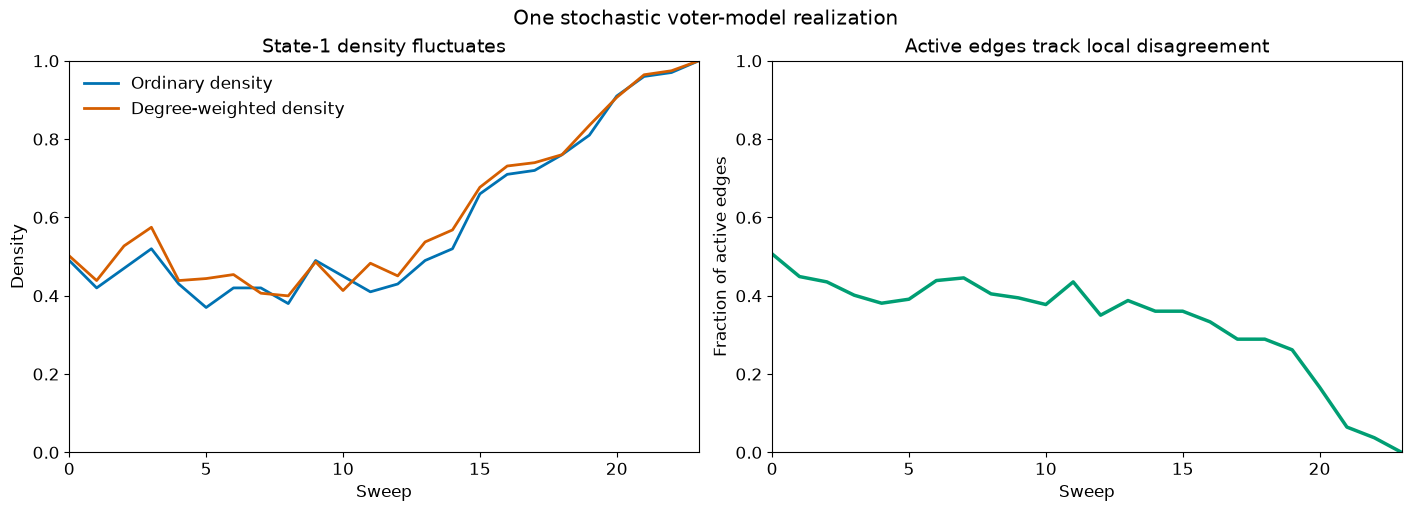

Initial ordinary density: 0.490
Initial degree-weighted density: 0.502
Final active-edge density: 0.000


In [13]:
sweeps = np.arange(len(state_history))
state_one_density = state_history.mean(axis=1)
degree_weighted_density = state_history @ degrees / degrees.sum()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    layout="constrained",
)

axes[0].plot(
    sweeps,
    state_one_density,
    color="#0072B2",
    linewidth=2,
    label="Ordinary density",
)
axes[0].plot(
    sweeps,
    degree_weighted_density,
    color="#D55E00",
    linewidth=2,
    label="Degree-weighted density",
)
axes[0].set(
    title="State-1 density fluctuates",
    xlabel="Sweep",
    ylabel="Density",
    xlim=(0, max(1, elapsed_sweeps)),
    ylim=(0, 1),
)
axes[0].legend(frameon=False)

axes[1].plot(
    sweeps,
    active_history,
    color="#009E73",
    linewidth=2.5,
)
axes[1].set(
    title="Active edges track local disagreement",
    xlabel="Sweep",
    ylabel="Fraction of active edges",
    xlim=(0, max(1, elapsed_sweeps)),
    ylim=(0, 1),
)

fig.suptitle("One stochastic voter-model realization")
plt.show()

print(f"Initial ordinary density: {state_one_density[0]:.3f}")
print(
    "Initial degree-weighted density:",
    f"{degree_weighted_density[0]:.3f}",
)
print(f"Final active-edge density: {active_history[-1]:.3f}")

## 5. A network-specific prediction: fixation probability

For this node-update rule on a finite connected undirected network, the probability of eventual all-$1$ consensus equals the initial degree-weighted density $\omega(0)$.

We keep the network and initial configuration fixed, then run independent stochastic trajectories. Their all-$1$ frequency is a finite-sample estimate of that probability, not a proof of the theoretical result.

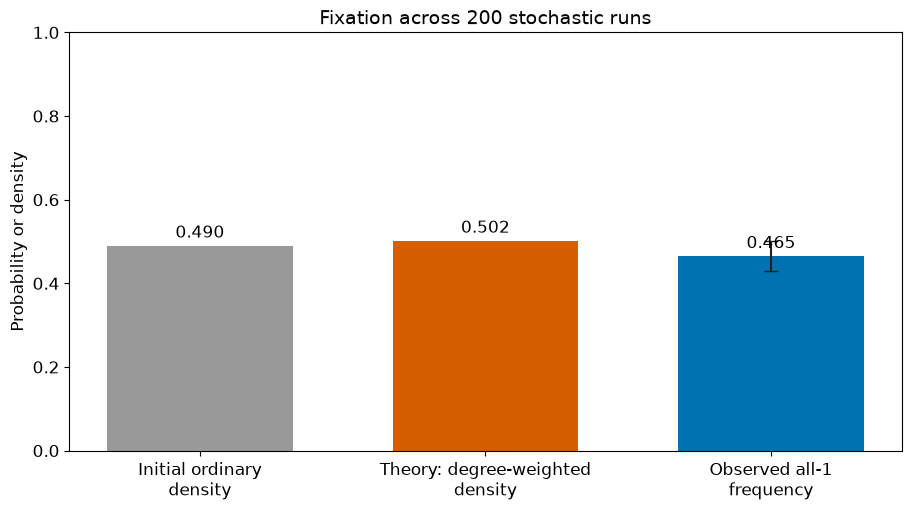

Resolved runs: 200/200
Unresolved runs: 0
Mean consensus time among resolved runs: 50.2 sweeps


In [14]:
def run_to_consensus(neighbors, initial_state, max_sweeps, rng):
    """Return the consensus state and sweep, or (None, None)."""
    states = np.asarray(initial_state, dtype=np.int8).copy()
    if np.all(states == states[0]):
        return int(states[0]), 0

    for sweep in range(1, max_sweeps + 1):
        voter_sweep(states, neighbors, rng)
        if np.all(states == states[0]):
            return int(states[0]), sweep

    return None, None


ensemble_rng = np.random.default_rng(ENSEMBLE_SEED)
outcomes = np.full(N_ENSEMBLE_RUNS, -1, dtype=np.int8)
consensus_times = np.full(N_ENSEMBLE_RUNS, np.nan)

for run_index in range(N_ENSEMBLE_RUNS):
    outcome, consensus_time = run_to_consensus(
        neighbor_ids,
        initial_states,
        MAX_SWEEPS,
        ensemble_rng,
    )
    if outcome is not None:
        outcomes[run_index] = outcome
        consensus_times[run_index] = consensus_time

resolved = outcomes >= 0
n_resolved = int(resolved.sum())
n_unresolved = N_ENSEMBLE_RUNS - n_resolved
assert n_resolved > 0, "Increase MAX_SWEEPS to observe resolved runs."

observed_all_one_frequency = np.mean(outcomes[resolved] == 1)
predicted_all_one_probability = degree_weighted_density[0]
sampling_error = np.sqrt(
    observed_all_one_frequency
    * (1 - observed_all_one_frequency)
    / n_resolved
)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
labels = [
    "Initial ordinary\ndensity",
    "Theory: degree-weighted\ndensity",
    "Observed all-1\nfrequency",
]
values = [
    state_one_density[0],
    predicted_all_one_probability,
    observed_all_one_frequency,
]
colors = ["#999999", "#D55E00", "#0072B2"]
bars = ax.bar(labels, values, color=colors, width=0.65)
ax.errorbar(
    2,
    observed_all_one_frequency,
    yerr=sampling_error,
    color="#222222",
    capsize=5,
    linewidth=1.5,
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(
    title=f"Fixation across {N_ENSEMBLE_RUNS} stochastic runs",
    ylabel="Probability or density",
    ylim=(0, 1),
)
plt.show()

print(f"Resolved runs: {n_resolved}/{N_ENSEMBLE_RUNS}")
print(f"Unresolved runs: {n_unresolved}")
if n_unresolved:
    print("Caution: the observed frequency uses resolved runs only.")
print(
    "Mean consensus time among resolved runs:",
    f"{np.nanmean(consensus_times):.1f} sweeps",
)

## Interpretation and limitations

The baseline trajectory illustrates how random local copying can remove disagreement and reach consensus without averaging opinions. Temporary reversals are expected: a stochastic path need not approach consensus smoothly.

The ensemble illustrates a network-specific theoretical result. Under node-update, placing state $1$ on higher-degree vertices raises its fixation probability because the degree-weighted—not ordinary—initial density is the relevant martingale.

These conclusions follow from the chosen mechanism and fixed network. They do not establish that real people copy neighbors uniformly, hold binary views, or keep social ties unchanged.

### Suggested experiments

1. Change INITIAL_ONE_PROBABILITY and compare fixation frequencies.
2. Change EDGES_PER_NEW_AGENT and compare consensus times.
3. Replace node-update with link-update and identify which density is conserved in expectation.

### References

1. Clifford, P., & Sudbury, A. (1973). A model for spatial conflict. *Biometrika*, 60(3), 581–588. [doi:10.1093/biomet/60.3.581](https://doi.org/10.1093/biomet/60.3.581)
2. Holley, R. A., & Liggett, T. M. (1975). Ergodic theorems for weakly interacting infinite systems and the voter model. *The Annals of Probability*, 3(4), 643–663. [doi:10.1214/aop/1176996306](https://doi.org/10.1214/aop/1176996306)
3. Sood, V., & Redner, S. (2005). Voter model on heterogeneous graphs. *Physical Review Letters*, 94, 178701. [doi:10.1103/PhysRevLett.94.178701](https://doi.org/10.1103/PhysRevLett.94.178701)